# Explora aquí

Se recomienda utilizar este cuaderno con fines de exploración.

In [2]:
#paso 2: descargar HTML
import pandas as pd
import requests
import sqlite3
from io import StringIO

url = "https://www.baseball-reference.com/leagues/majors/2025-standard-batting.shtml"
headers = {"User-Agent": "Mozilla/5.0"}

response = requests.get(url, headers=headers)

if response.status_code == 200:
    html_content = response.text
    print("Descarga exitosa (CODE: 200)")
else:
    print(f"Error al descargar: {response.status_code}")

Descarga exitosa (CODE: 200)


In [3]:
# paso 3: Transformar HTML
# Usamos StringIO para que pandas no busque un archivo físico
html_data = StringIO(response.text)
tablas = pd.read_html(html_data)
df = tablas[0]

In [4]:
#paso 4: procesar DF
print("Columnas detectadas originalmente:", df.columns.tolist())

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(-1)

df.columns = df.columns.astype(str).str.strip()

col_nombre = ''
if 'Name' in df.columns:
    col_nombre = 'Name'
elif 'Player' in df.columns:
    col_nombre = 'Player'
else:
    col_nombre = df.columns[1]

print(f"Usando la columna '{col_nombre}' para limpiar filas...")

df = df[df[col_nombre] != col_nombre].copy()

cols_a_numeros = ['G', 'AB', 'R', 'H', 'HR', 'RBI', 'BA', 'OPS']
for col in cols_a_numeros:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

Columnas detectadas originalmente: ['Tm', '#Bat', 'BatAge', 'R/G', 'G', 'PA', 'AB', 'R', 'H', '2B', '3B', 'HR', 'RBI', 'SB', 'CS', 'BB', 'SO', 'BA', 'OBP', 'SLG', 'OPS', 'OPS+', 'TB', 'GDP', 'HBP', 'SH', 'SF', 'IBB', 'LOB']
Usando la columna '#Bat' para limpiar filas...


In [5]:
# paso 5: almacenamiento de datos SQlite
conexion = sqlite3.connect('mlb_2025_proyecto.db')
df_graficos = pd.read_sql_query("SELECT * FROM bateo", conexion)
conexion.close()


top_10_ba.png


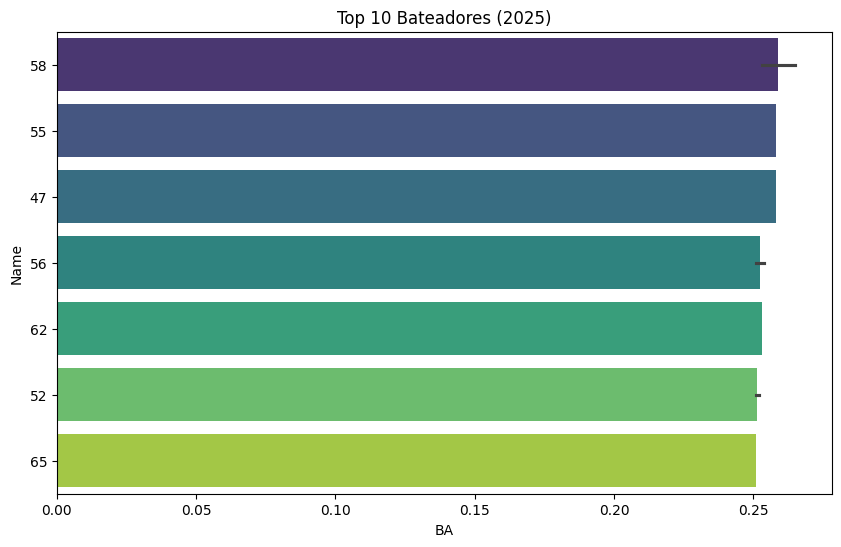

In [6]:
# paso 6: visualizacion de datos top 10 Jugadores con mejor Promedio de Bateo
import matplotlib.pyplot as plt
import seaborn as sns

conexion = sqlite3.connect('mlb_2025_proyecto.db')
df_graficos = pd.read_sql_query("SELECT * FROM bateo", conexion)
conexion.close()

df_graficos.columns.values[1] = 'Name'
df_graficos.columns.values[3] = 'Team'

df_graficos.columns = df_graficos.columns.str.strip()

df_graficos['BA'] = pd.to_numeric(df_graficos['BA'], errors='coerce')
df_graficos['HR'] = pd.to_numeric(df_graficos['HR'], errors='coerce')
df_graficos['AB'] = pd.to_numeric(df_graficos['AB'], errors='coerce')

# Grafica
plt.figure(figsize=(10, 6))
top_10 = df_graficos[df_graficos['AB'] > 10].sort_values('BA', ascending=False).head(10)
sns.barplot(data=top_10, x='BA', y='Name', hue='Name', palette='viridis', legend=False)
plt.title('Top 10 Bateadores (2025)')
plt.savefig('top_10_ba.png')
print("top_10_ba.png")
plt.show()